In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# **Import Data**

source: https://archive.ics.uci.edu/dataset/292/wholesale+customers

In [55]:
df = pd.read_csv("customer.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


* null check
* data imputation
* etc.
# **Data Preprocessing**

In [56]:
df.info

<bound method DataFrame.info of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0          2       3  12669   9656     7561     214              2674   
1          2       3   7057   9810     9568    1762              3293   
2          2       3   6353   8808     7684    2405              3516   
3          1       3  13265   1196     4221    6404               507   
4          2       3  22615   5410     7198    3915              1777   
..       ...     ...    ...    ...      ...     ...               ...   
435        1       3  29703  12051    16027   13135               182   
436        1       3  39228   1431      764    4510                93   
437        2       3  14531  15488    30243     437             14841   
438        1       3  10290   1981     2232    1038               168   
439        1       3   2787   1698     2510      65               477   

     Delicassen  
0          1338  
1          1776  
2          7844  
3          1788  
4

In [57]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [60]:
spending_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

In [61]:
X = df[spending_cols].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Exploratory Data Analysis**

# **Determine the number of clusters, training fit, predict, and cluster analysis**

In [62]:
#Choose K using silhouette 
sil_scores = []
inertias = []
ks = list(range(2, 11))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"k={k} inertia={km.inertia_:.3f} silhouette={sil:.4f}")

best_k = ks[int(np.argmax(sil_scores))]
print("\nBest k by silhouette:", best_k)

k=2 inertia=1954.648 silhouette=0.6137
k=3 inertia=1608.431 silhouette=0.5483
k=4 inertia=1317.838 silhouette=0.3485
k=5 inertia=1058.771 silhouette=0.3690
k=6 inertia=915.741 silhouette=0.3782
k=7 inertia=822.722 silhouette=0.3035
k=8 inertia=737.386 silhouette=0.3201
k=9 inertia=661.450 silhouette=0.3090
k=10 inertia=605.915 silhouette=0.3112

Best k by silhouette: 2


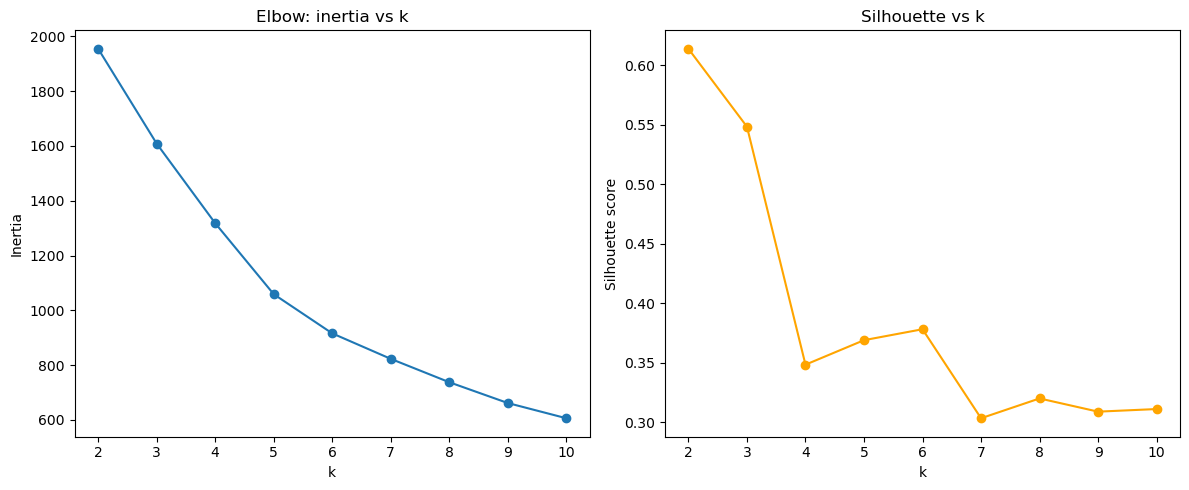

In [63]:
# Plot elbow 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ks, inertias, '-o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow: inertia vs k")

plt.subplot(1, 2, 2)
plt.plot(ks, sil_scores, '-o', color='orange')
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette vs k")
plt.tight_layout()
plt.savefig("k_selection_elbow_silhouette.png", dpi=150)
plt.show()

In [64]:
# Fit final KMeans with the chosen k
final_k = best_k
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=50)
labels = kmeans.fit_predict(X_scaled)

In [65]:
# Attach cluster labels to original df
df['Cluster'] = labels

In [66]:
#Cluster centers 
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers, columns=spending_cols)
centers_df.index.name = "Cluster"
print("\nCluster centers (original scale):")
print(centers_df.round(2))


Cluster centers (original scale):
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0        11983.60   4260.88   5782.84  3056.10           1773.71     1302.69
1        12167.32  21150.08  29635.68  3230.28          13959.30     3746.70


In [67]:
counts = df['Cluster'].value_counts().sort_index()
print("\nCluster sizes:")
print(counts)

cluster_profile = df.groupby('Cluster')[spending_cols].mean().round(2)
print("\nCluster mean (original scale):")
print(cluster_profile)


Cluster sizes:
Cluster
0    400
1     40
Name: count, dtype: int64

Cluster mean (original scale):
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0        11983.60   4260.88   5782.84  3056.10           1773.71     1302.69
1        12167.32  21150.08  29635.68  3230.28          13959.30     3746.70


In [68]:
# Percent of total spending by cluster
df['TotalSpend'] = df[spending_cols].sum(axis=1)
cluster_spend = df.groupby('Cluster')['TotalSpend'].sum()
cluster_spend_pct = (cluster_spend / cluster_spend.sum() * 100).round(2)
print("\nCluster total spend and percent of total:")
print(pd.concat([cluster_spend, cluster_spend_pct.rename('PctTotal')], axis=1))


Cluster total spend and percent of total:
         TotalSpend  PctTotal
Cluster                      
0          11263926     77.05
1           3355574     22.95


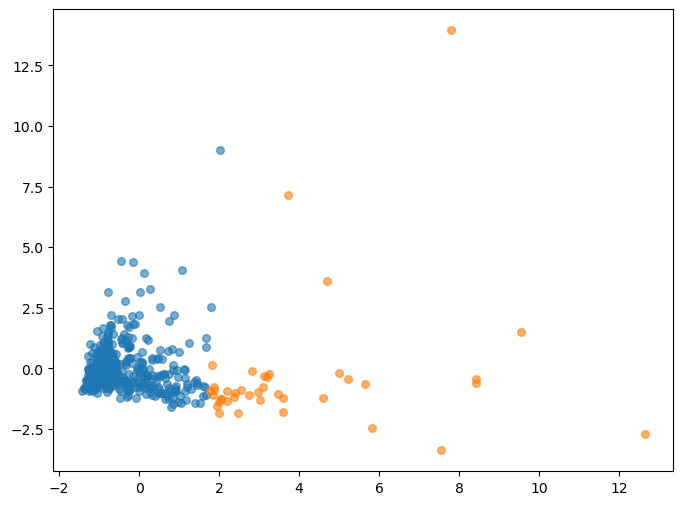

In [69]:
#PCA 2D plot
pca = PCA(n_components=2, random_state=70)
proj = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
palette = sns.color_palette("tab10", final_k)
for i in range(final_k):
    idx = labels == i
    plt.scatter(proj[idx, 0], proj[idx, 1], s=30, alpha=0.6, label=f"Cluster {i}", color=palette[i])

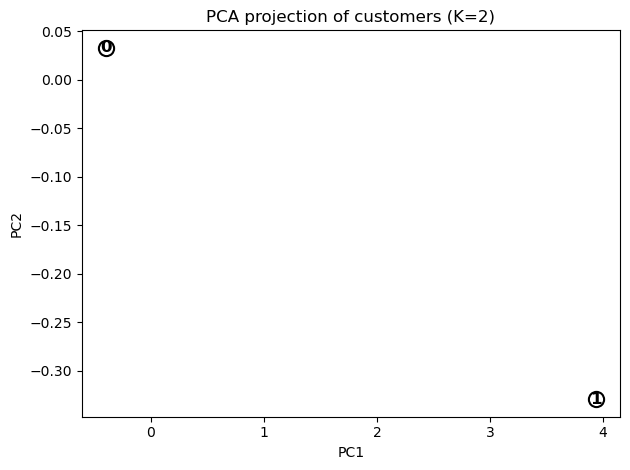

In [70]:
# project centers
centers_proj = pca.transform(centers_scaled)
plt.scatter(centers_proj[:, 0], centers_proj[:, 1], c='white', edgecolors='k', s=120, linewidths=1.5)
for i, (x, y) in enumerate(centers_proj):
    plt.text(x, y, str(i), fontsize=12, fontweight='bold', ha='center', va='center')
plt.title(f"PCA projection of customers (K={final_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

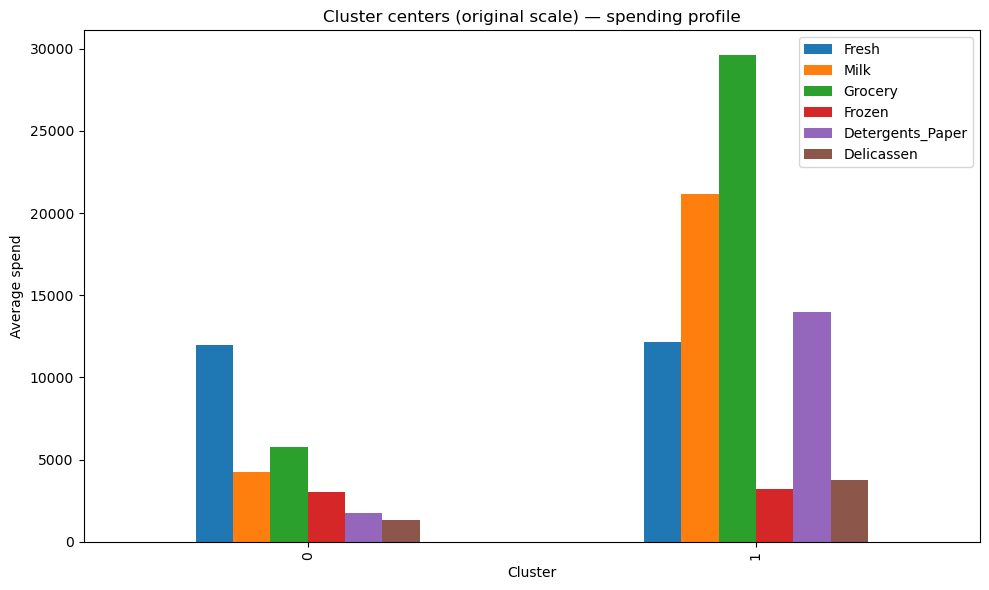

In [71]:
#Bar chart of centers to summarize segment profiles
centers_df_norm.plot(kind='bar', figsize=(10, 6))
plt.title("Cluster centers (original scale) — spending profile")
plt.xlabel("Cluster")
plt.ylabel("Average spend")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()